In [2]:
from tqdm import tqdm
import os
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [3]:
from imcui.api.core import ImageMatchingAPI
import cv2
from imcui.ui.viz import display_matches
from imcui.ui.utils import wrap_images

[2025/10/24 18:51:57 hloc WARNING] pycolmap is not installed, some features may not work.
[2025/10/24 18:51:59 hloc INFO] ARCSizeAwareModelCache initialized.


In [4]:
import numpy as np

def stack_images_grid(images, rows=3, cols=3):
    """
    Stack a list of images (numpy arrays) into a grid.
    
    Args:
        images: list of np.ndarray, each (H, W, C)
        rows, cols: number of grid rows/cols (default 3x3)
    
    Returns:
        grid (H*rows, W*cols, C) as np.ndarray
    """
    assert len(images) == rows * cols, f"Need {rows*cols} images, got {len(images)}"
    h, w, c = images[0].shape
    for img in images:
        assert img.shape == (h, w, c), "All images must have the same shape"
    
    rows_arr = []
    for i in range(rows):
        row_imgs = images[i * cols:(i + 1) * cols]
        row = np.concatenate(row_imgs, axis=1)
        rows_arr.append(row)
    grid = np.concatenate(rows_arr, axis=0)
    return grid

In [5]:
conf = {
    "ransac": {
        "enable": True,
        "estimator": "poselib",
        "geometry": "homography",
        "method": "cv2_USAC_MAGSAC",
        "reproj_threshold": 2,
        "confidence": 0.9999,
        "max_iter": 100000,
    },
    "matcher": {
        "output": "matches-minima_roma",
        "model": {
            "name": "roma",
            "weights": "outdoor",
            "model_name": "minima_roma.pth",
            "max_keypoints": 4000,
            "match_threshold": 0.2,
        },
        "preprocessing": {
            "grayscale": False,
            "force_resize": True,
            "resize_max": 1536,
            "width": 320,
            "height": 240,
            "dfactor": 8,
        },
    },
    "dense": True,
}

api = ImageMatchingAPI(conf=conf, device="cuda:0")

print(api)
print(api.conf)

[2025/10/24 18:51:59 hloc INFO] Loading Roma model
[2025/10/24 18:52:04 hloc INFO] Load Roma model done.


ImageMatchingAPI(
  (matcher): Roma(
    (net): RegressionMatcher(
      (encoder): CNNandDinov2(
        (cnn): VGG19(
          (layers): ModuleList(
            (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
            (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (5): ReLU(inplace=True)
            (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
            (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (9): ReLU(inplace=True)
            (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (11): Bat

NUMBER OF IDS: 5


0it [00:00, ?it/s][2025/10/27 04:33:41 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:33:41 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


0 2659677149 3 0 1718


[2025/10/27 04:33:42 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:33:42 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


0 2659677149 3 1 60


...

0 2659677149 12 1 54


[2025/10/27 04:34:03 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:34:03 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


0 2659677149 12 2 66


[2025/10/27 04:34:03 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:34:03 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


0 2659677149 12 3 614


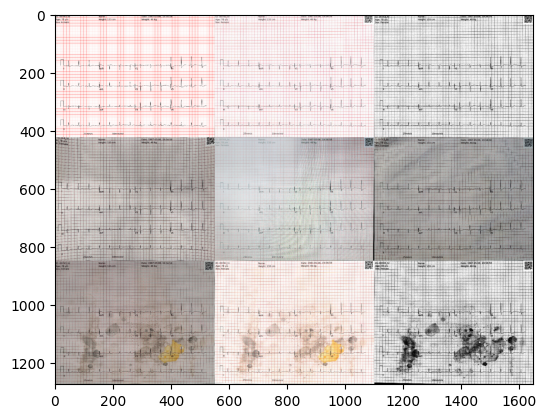

1it [00:23, 23.18s/it][2025/10/27 04:34:04 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:34:04 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


1 668648821 3 0 1671


[2025/10/27 04:34:05 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:34:05 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


1 668648821 3 1 51


[2025/10/27 04:34:06 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:34:06 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


...

1 668648821 12 1 27


[2025/10/27 04:34:26 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:34:26 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


1 668648821 12 2 31


[2025/10/27 04:34:27 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:34:27 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


1 668648821 12 3 901


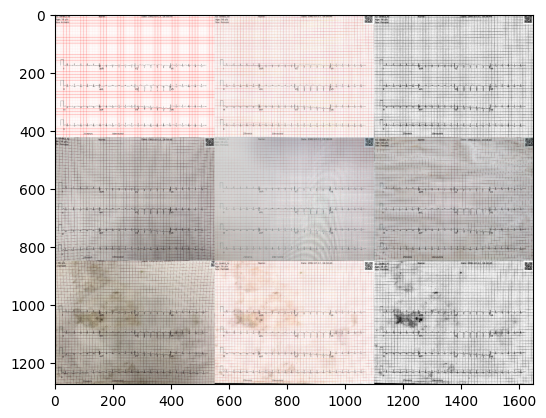

2it [00:46, 23.27s/it][2025/10/27 04:34:28 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:34:28 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


2 3918873626 3 0 1647


[2025/10/27 04:34:28 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:34:28 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


2 3918873626 3 1 27


[2025/10/27 04:34:29 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:34:29 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


...

2 3918873626 12 1 44


[2025/10/27 04:34:49 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:34:50 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


2 3918873626 12 2 27


[2025/10/27 04:34:50 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:34:50 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


2 3918873626 12 3 809


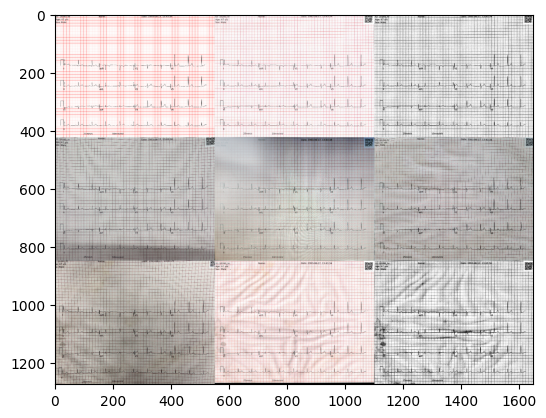

3it [01:09, 23.36s/it][2025/10/27 04:34:51 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:34:51 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


3 3850187418 3 0 1855


[2025/10/27 04:34:52 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:34:52 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


3 3850187418 3 1 50


[2025/10/27 04:34:52 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:34:53 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


...

3 3850187418 12 1 23


[2025/10/27 04:35:12 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:35:12 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


3 3850187418 12 2 116


[2025/10/27 04:35:13 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:35:13 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


3 3850187418 12 3 917


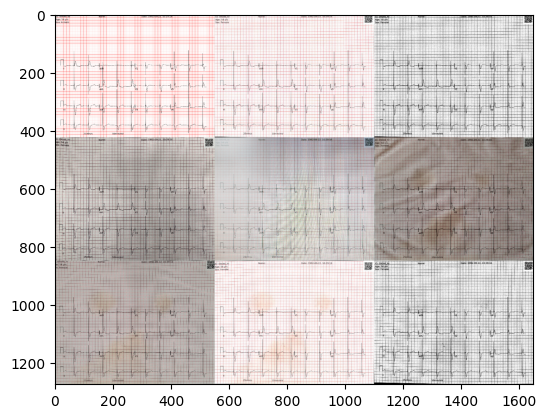

4it [01:32, 22.95s/it][2025/10/27 04:35:13 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:35:13 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


4 3547378375 3 0 1480


[2025/10/27 04:35:14 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:35:14 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


4 3547378375 3 1 45


[2025/10/27 04:35:15 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:35:15 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


...

4 3547378375 12 1 41


[2025/10/27 04:35:35 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:35:35 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


4 3547378375 12 2 76


[2025/10/27 04:35:35 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/10/27 04:35:35 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


4 3547378375 12 3 1133


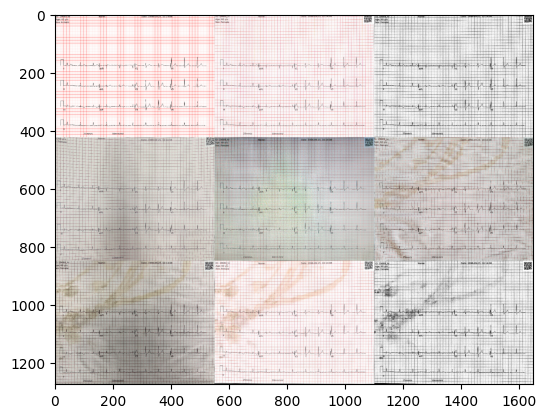

5it [01:54, 22.99s/it]


In [58]:
IMG_DIR = '/home/dangnh36/datasets/ecg/raw/train/'
SAVE_VIZ_DIR = '/home/dangnh36/datasets/ecg/processed/imc_viz/'
os.makedirs(SAVE_VIZ_DIR, exist_ok=True)

ROT_TRIALS = [None, cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_90_COUNTERCLOCKWISE, cv2.ROTATE_180]
# ROT_TRIALS = [None]

sids = os.listdir(IMG_DIR)

sids = ['2659677149', '668648821', '3918873626', '3850187418', '3547378375']

print('NUMBER OF IDS:', len(sids))

ret = {}
for sid_idx, sid in tqdm(enumerate(sids)):
    sid_ret = {}
    ref_img_path = os.path.join(IMG_DIR, sid, f'{sid}-0001.png')
    ref_img = cv2.cvtColor(cv2.imread(ref_img_path), cv2.COLOR_BGR2RGB)
    REF_H, REF_W = ref_img.shape[:2]
    REF_VIZ_H, REF_VIZ_W = REF_H // 4, REF_W // 4

    vizs = [cv2.resize(ref_img, (REF_VIZ_W, REF_VIZ_H))]
    for type_idx in [3, 4, 5, 6, 9, 10, 11, 12]:
    # for type_idx in [10, 11, 12]:
        img_path = os.path.join(IMG_DIR, sid, f'{sid}-{type_idx:04d}.png')
        ori_img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

        rot_trial_Hs = []
        rot_trial_num_matches = []
        for rot_idx, rot_trial in enumerate(ROT_TRIALS):
            # dict_keys(['image0', 'image1', 'image0_orig', 'image1_orig', 'keypoints0', 'keypoints1', 'keypoints0_orig', 'keypoints1_orig', 
            # 'mkeypoints0', 'mkeypoints1', 'mkeypoints0_orig', 'mkeypoints1_orig', 'original_size0', 'original_size1', 'new_size0', 'new_size1',
            # 'scale0', 'scale1', 'mconf', 'mmkeypoints0_orig', 'mmkeypoints1_orig', 'mmconf', 'H', 'geom_info'])
            if rot_trial is not None:
                img = cv2.rotate(ori_img, rot_trial)
            else:
                img = ori_img
            pred = api(img, ref_img)
            H = pred['geom_info']['Homography']
            assert len(pred['mmkeypoints0_orig']) == len(pred['mmkeypoints1_orig'])
            num_matches = len(pred['mmkeypoints1_orig'])
            print(sid_idx, sid, type_idx, rot_idx, num_matches)
            
            rot_trial_Hs.append(H)
            rot_trial_num_matches.append(num_matches)
            
            # if num_matches < 3000:
            #     print('+++MAY BE ROTATED:', sid_idx, sid, type_idx, rot_idx, rot_trial)
            # else:
            #     break

        assert len(rot_trial_Hs) == len(rot_trial_num_matches)
        tmp = np.array(rot_trial_num_matches).copy()
        tmp[0] *= 1.2
        select_idx = int(np.argmax(tmp))
        H = rot_trial_Hs[select_idx]
        if select_idx != 0:
            print('OK, CORRECT ROTATION TO', select_idx, ROT_TRIALS[select_idx])
            img = cv2.rotate(ori_img, ROT_TRIALS[select_idx])
        else:
            img = ori_img
        sid_ret[type_idx] = [select_idx, ROT_TRIALS[select_idx], rot_trial_num_matches[select_idx], H]
            # print(type_idx, H)
    
            # _viz, _warp1 = wrap_images(
            #     ref_img, img,
            #     geo_info = {'Homography': np.linalg.inv(H)},
            #     geom_type = 'Homography',
            # )
            # plt.close()
    
        warp1 = cv2.warpPerspective(img, np.array(H), (REF_W, REF_H))
        
        vizs.append(
            cv2.resize(warp1, (REF_VIZ_W, REF_VIZ_H))
        )

    ret[sid] = sid_ret
    viz = stack_images_grid(vizs, rows=3, cols=3)
    
    plt.imshow(viz)
    plt.show()
    plt.close()

    cv2.imwrite(os.path.join(SAVE_VIZ_DIR, f'{sid}.png'), cv2.cvtColor(viz, cv2.COLOR_RGB2BGR))

In [61]:
len(ret)

5

In [62]:
ret2 = ret

In [ ]:
img.shape

In [ ]:
list(ret.keys())[0]

In [ ]:
ret['4006376611']

In [ ]:
# for sid, sid_v in ret.items():
#     for type_idx, v in sid_v.items():
#         v[0] = int(v[0])

In [65]:
import json

with open('/home/dangnh36/datasets/ecg/processed/imc_results.json', 'w') as f:
    json.dump(ret, f)

In [69]:
import json

with open('/home/dangnh36/datasets/ecg/processed/imc_results.json', 'r') as f:
    ret = json.load(f)
print(len(ret))

977


In [70]:
# ret.update(ret2)

In [ ]:
for sid, sid_v in ret.items():
    do_viz = False
    for type_idx, v in sid_v.items():
        if v[1] is not None:
            do_viz = True
            print(sid, type_idx, v[0], v[-2])
    if do_viz:
        print(f'------------{sid}-----------')
        print([e[-2] for e in sid_v.values()])
        img = cv2.imread(f'/home/dangnh36/datasets/ecg/processed/imc_viz/{sid}.png')
        plt.imshow(img)
        plt.show()